# 0. XGBoost 모델 공부

## 0-1. XGBoost의 원리

XGBoost는 **Gradient Boosting Decision Tree** 계열의 앙상블 모델이다.

하나의 복잡한 의사결정나무를 한 번에 만드는 대신, 비교적 작은 나무를 순서대로 추가한다.  
새로운 나무는 앞에서 만든 모델이 잘못 예측한 부분을 보완하도록 학습한다.

### 학습 과정

1. 첫 번째 의사결정나무가 예측한다.
2. 실제값과 예측값 사이의 오차를 계산한다.
3. 다음 나무가 앞 모델의 오차를 줄이는 방향으로 학습한다.
4. 여러 개의 나무를 순차적으로 추가한다.
5. 각 나무의 결과를 합하여 최종 예측 확률과 클래스를 계산한다.

## 0-2. XGBoost의 특징

### 장점

- 표 형식의 정형 데이터에서 높은 예측 성능을 보이는 경우가 많다.
- 비선형 관계와 변수 간 상호작용을 학습할 수 있다.
- L1·L2 규제 기능을 이용하여 과적합을 줄일 수 있다.
- 행과 변수를 일부만 사용하는 샘플링 기능이 있다.
- 학습 후 변수 중요도를 확인할 수 있다.
- 트리 기반 모델이므로 일반적으로 변수 표준화가 필수는 아니다.

### 단점

- 조정할 수 있는 하이퍼파라미터가 많다.
- 나무가 너무 깊거나 개수가 지나치게 많으면 과적합될 수 있다.
- 로지스틱 회귀처럼 계수만으로 변수의 영향 방향을 직접 설명하기 어렵다.
- 탐색할 하이퍼파라미터 조합이 많으면 학습 시간이 길어질 수 있다.

### 주로 사용하는 상황

- 당뇨병 여부처럼 목표변수가 0과 1인 이진 분류
- 고객 이탈, 부도, 이상 거래, 질병 위험 예측
- 숫자형 변수가 많은 표 형식 데이터
- 변수 간 관계가 단순한 직선 형태가 아닐 것으로 예상되는 데이터

## 0-3. 주요 하이퍼파라미터

| 하이퍼파라미터 | 의미 | 값을 조정했을 때의 영향 |
|---|---|---|
| `n_estimators` | 생성할 의사결정나무의 수 | 너무 크면 학습 시간이 늘고 과적합 가능성이 커질 수 있음 |
| `learning_rate` | 각 나무가 이전 모델을 보완하는 정도 | 작을수록 천천히 학습하며 보통 더 많은 나무가 필요함 |
| `max_depth` | 각 나무의 최대 깊이 | 클수록 복잡한 패턴을 학습하지만 과적합 위험이 증가함 |
| `min_child_weight` | 자식 노드 분할에 필요한 최소 가중치 | 클수록 분할이 보수적으로 이루어짐 |
| `gamma` | 추가 분할에 필요한 최소 손실 감소량 | 클수록 불필요한 분할을 줄임 |
| `subsample` | 각 나무를 만들 때 사용할 행의 비율 | 1보다 작으면 일부 행만 사용하여 과적합 완화 가능 |
| `colsample_bytree` | 각 나무를 만들 때 사용할 변수의 비율 | 1보다 작으면 일부 변수만 사용하여 과적합 완화 가능 |
| `reg_alpha` | L1 규제 강도 | 커질수록 모델이 보수적으로 학습됨 |
| `reg_lambda` | L2 규제 강도 | 커질수록 모델이 보수적으로 학습됨 |
| `scale_pos_weight` | 양성 클래스 가중치 | 클래스 불균형이 있을 때 양성 클래스 학습을 강화함 |
| `objective` | 학습 목적함수 | 이진 분류에서는 `binary:logistic` 사용 |
| `eval_metric` | 평가 기준 | `logloss`, `auc` 등을 사용할 수 있음 |

이번 과제에서는 `n_estimators`, `learning_rate`, `max_depth`, `min_child_weight`,  
`subsample`, `colsample_bytree`, `scale_pos_weight`를 조정한다.

# EDA

In [67]:
# %pip install -U scikit-learn xgboost

In [68]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from IPython.display import display

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn import set_config
set_config(display="text")

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 1234

# 1. 데이터 확인

In [69]:
df = pd.read_csv('datas/diabetes.csv')
df_raw = df # 원본 데이터 df_raw 이름으로 저장
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6000,0.6270,50,1
1,1,85,66,29,0,26.6000,0.3510,31,0
2,8,183,64,0,0,23.3000,0.6720,32,1
3,1,89,66,23,94,28.1000,0.1670,21,0
4,0,137,40,35,168,43.1000,2.2880,33,1


In [70]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9000,0.1710,63,0
764,2,122,70,27,0,36.8000,0.3400,27,0
765,5,121,72,23,112,26.2000,0.2450,30,0
766,1,126,60,0,0,30.1000,0.3490,47,1
767,1,93,70,31,0,30.4000,0.3150,23,0


데이터 열 의미

| 변수 | 의미 |
|---|---|
| `Pregnancies` | 임신 횟수 |
| `Glucose` | 혈장 포도당 농도 |
| `BloodPressure` | 이완기 혈압 |
| `SkinThickness` | 삼두근 피부 두께 |
| `Insulin` | 2시간 혈청 인슐린 |
| `BMI` | 체질량지수 |
| `DiabetesPedigreeFunction` | 당뇨병 가족력 함수 |
| `Age` | 나이 |
| `Outcome` | 당뇨병 여부(0=당뇨병x, 1=당뇨병o) |

In [71]:
# 데이터 변수별(열별) 구조 확인

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [72]:
# 결측 중복 수 확인
print("중복 행 수:", df_raw.duplicated().sum())

print("\n변수별 결측치 수")
display(df_raw.isna().sum().to_frame("결측치 수"))

print("\n기술통계")
display(df_raw.describe().T)

중복 행 수: 0

변수별 결측치 수


,결측치 수
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



기술통계


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0000,3.8451,3.3696,0.0000,1.0000,3.0000,6.0000,17.0000
Glucose,768.0000,120.8945,31.9726,0.0000,99.0000,117.0000,140.2500,199.0000
BloodPressure,768.0000,69.1055,19.3558,0.0000,62.0000,72.0000,80.0000,122.0000
SkinThickness,768.0000,20.5365,15.9522,0.0000,0.0000,23.0000,32.0000,99.0000
Insulin,768.0000,79.7995,115.2440,0.0000,0.0000,30.5000,127.2500,846.0000
BMI,768.0000,31.9926,7.8842,0.0000,27.3000,32.0000,36.6000,67.1000
DiabetesPedigreeFunction,768.0000,0.4719,0.3313,0.0780,0.2437,0.3725,0.6262,2.4200
Age,768.0000,33.2409,11.7602,21.0000,24.0000,29.0000,41.0000,81.0000
Outcome,768.0000,0.3490,0.4770,0.0000,0.0000,0.0000,1.0000,1.0000


# 1. 데이터 구조 인사이트

- 목표변수(당뇨병,Y)는 `Outcome`이며, 나머지 8개 변수는 설명변수이다.
- 원본 데이터에 `NaN` 형태의 결측치가 없더라도 일부 건강 측정값의 0은 실제 측정값이 아니라 누락을 0으로 기록한 값일 수 있다.
- 따라서 `isna()` 결과만 확인하지 않고 각 변수의 의미와 0값의 빈도를 함께 확인해야 한다.

# 0값 처리 기준

| 변수 | 0 가능 여부 | 전처리 기준 |
|---|---|---|
| Pregnancies(임신횟수) | 가능 | 임신 경험이 없으면 0일 수 있으므로 유지 |
| Glucose(혈장 포도당 농도) | 현실적인 측정값으로 보기 어려움 | 0을 결측값으로 처리 |
| BloodPressure(혈압) | 현실적인 측정값으로 보기 어려움 | 0을 결측값으로 처리 |
| SkinThickness(삼두근 피부 두께) | 현실적인 측정값으로 보기 어려움 | 0을 결측값으로 처리 |
| Insulin(인슐린 분비량) | 0을 정상 측정치로 단정하기 어려움 | 0을 결측값으로 처리 |
| BMI(키 무게 비율) | 현실적인 값으로 보기 어려움 | 0을 결측값으로 처리 |
| DiabetesPedigreeFunction(가족력 점수) | 0이 나올 수 있음 | 원본 유지 |
| Age(나이) | 실제 나이로 불가능 | 0이 있으면 결측값으로 처리 |

### 1. DiabetesPedigreeFunction(당뇨병 가족력 점수) : 점수가 낮으면 가족력에 따른 위험이 비교적 낮은 편이라고 해석 
### -> 0이 나올 수 있다.

## 2. Insulin 처리 시 주의!! (타깃 누수)
원래라면 outcome 결과에 따라서 인슐린 데이터를 다르게 적용하는게 합리적이라고 생각하지만

기본 상식 :
`Outcome=1`인 데이터(행)는 `Insulin=0`은 1형 당뇨 가능성으로 보고 유지하고,  
`Outcome=0`인 데이터(행)는 실제로 0이 아닐 가능성이 높으므로 나머지 데이터의 중앙값으로 임시 대체한다.

이렇게 되면 타깃 누수 즉, 이미 데이터의 결과(Y)를 보고 설명변수를 채우는 타깃 누수가 발생한다.
따라서 실제 새로운 환자를 예측할 때는 그 환자의 outcome을 모르기 때문에 인슐린의 값이 0인 데이터에는 모두 정상 인슐린(0이 아닌 인슐린)의 중앙값으로 대체한다.


# 1-2. 각 데이터 변수 확인

각 변수마다 다음 내용을 확인한다.

- 기술통계
- 0의 개수와 비율
- Outcome별 평균·중앙값
- 전체 분포
- Outcome별 박스플롯

In [73]:
def numeric_eda(data, column, zero_policy):
    zero_count = int((data[column] == 0).sum())
    zero_rate = zero_count / len(data)

    print(f"[{column}]")
    print(f"0의 개수: {zero_count}")
    print(f"0의 비율: {zero_rate:.2%}")
    print(f"0 처리 기준: {zero_policy}")

    print("\n기술통계")
    display(data[column].describe().to_frame().T)

    grouped = data.groupby("Outcome")[column].agg(
        ["count", "mean", "median", "std", "min", "max"]
    )

    print("\nOutcome별 통계")
    display(grouped)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(data[column].dropna(), bins=25, edgecolor="black")
    axes[0].set_title(f"{column} 전체 분포")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("빈도")

    data.boxplot(column=column, by="Outcome", ax=axes[1])
    axes[1].set_title(f"{column}: Outcome별 분포")
    axes[1].set_xlabel("Outcome")
    axes[1].set_ylabel(column)

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

    median_0 = grouped.loc[0, "median"] if 0 in grouped.index else np.nan
    median_1 = grouped.loc[1, "median"] if 1 in grouped.index else np.nan

    print("자동 비교")
    if pd.notna(median_0) and pd.notna(median_1):
        if median_1 > median_0:
            print("- Outcome=1 집단의 중앙값이 Outcome=0 집단보다 높다.")
        elif median_1 < median_0:
            print("- Outcome=1 집단의 중앙값이 Outcome=0 집단보다 낮다.")
        else:
            print("- 두 집단의 중앙값이 같다.")

    if zero_count > 0:
        print(f"- 전체 {len(data)}개 행 중 {zero_count}개 행에서 0이 확인되었다.")
    else:
        print("- 0으로 기록된 값은 확인되지 않았다.")

### 1. Pregnancies

임신 횟수는 실제로 0이 가능하므로 정상값으로 유지한다.

[Pregnancies]
0의 개수: 111
0의 비율: 14.45%
0 처리 기준: 임신 경험이 없으면 0일 수 있으므로 정상값으로 유지

기술통계


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0000,3.8451,3.3696,0.0000,1.0000,3.0000,6.0000,17.0000



Outcome별 통계


,count,mean,median,std,min,max
Outcome,,,,,,
0,500,3.2980,2.0000,3.0172,0,13
1,268,4.8657,4.0000,3.7412,0,17


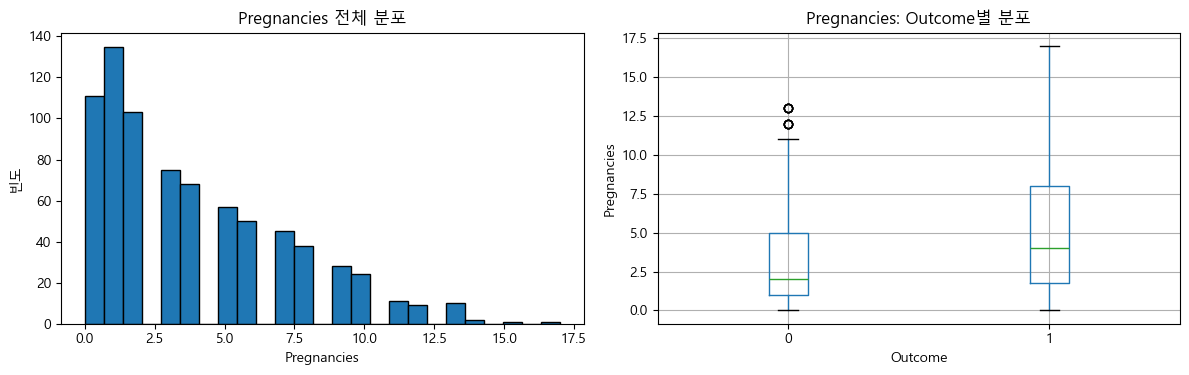

자동 비교
- Outcome=1 집단의 중앙값이 Outcome=0 집단보다 높다.
- 전체 768개 행 중 111개 행에서 0이 확인되었다.


In [74]:
numeric_eda(
    df_raw,
    column="Pregnancies",
    zero_policy="임신 경험이 없으면 0일 수 있으므로 정상값으로 유지"
)

### 2. Glucose

혈장 포도당 농도이다. 0은 현실적인 측정값으로 보기 어려우므로 결측값으로 처리한다.

[Glucose]
0의 개수: 5
0의 비율: 0.65%
0 처리 기준: 0은 현실적인 측정값으로 보기 어려우므로 결측값으로 변경

기술통계


,count,mean,std,min,25%,50%,75%,max
Glucose,768.0000,120.8945,31.9726,0.0000,99.0000,117.0000,140.2500,199.0000



Outcome별 통계


,count,mean,median,std,min,max
Outcome,,,,,,
0,500,109.9800,107.0000,26.1412,0,197
1,268,141.2575,140.0000,31.9396,0,199


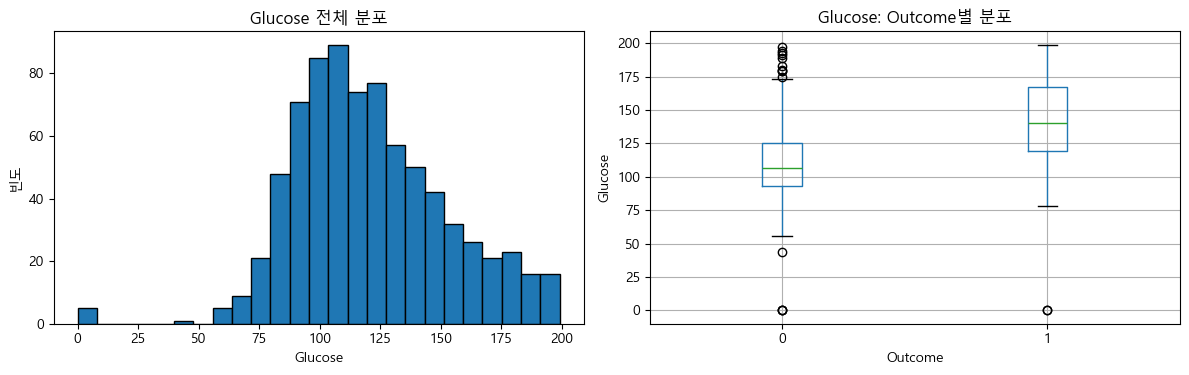

자동 비교
- Outcome=1 집단의 중앙값이 Outcome=0 집단보다 높다.
- 전체 768개 행 중 5개 행에서 0이 확인되었다.


In [75]:
numeric_eda(
    df_raw,
    column="Glucose",
    zero_policy="0은 현실적인 측정값으로 보기 어려우므로 결측값으로 변경"
)

### 3. BloodPressure

이완기 혈압이다. 0은 현실적인 혈압 측정값으로 보기 어려우므로 결측값으로 처리한다.

[BloodPressure]
0의 개수: 35
0의 비율: 4.56%
0 처리 기준: 0은 현실적인 혈압 측정값으로 보기 어려우므로 결측값으로 변경

기술통계


,count,mean,std,min,25%,50%,75%,max
BloodPressure,768.0000,69.1055,19.3558,0.0000,62.0000,72.0000,80.0000,122.0000



Outcome별 통계


,count,mean,median,std,min,max
Outcome,,,,,,
0,500,68.1840,70.0000,18.0631,0,122
1,268,70.8246,74.0000,21.4918,0,114


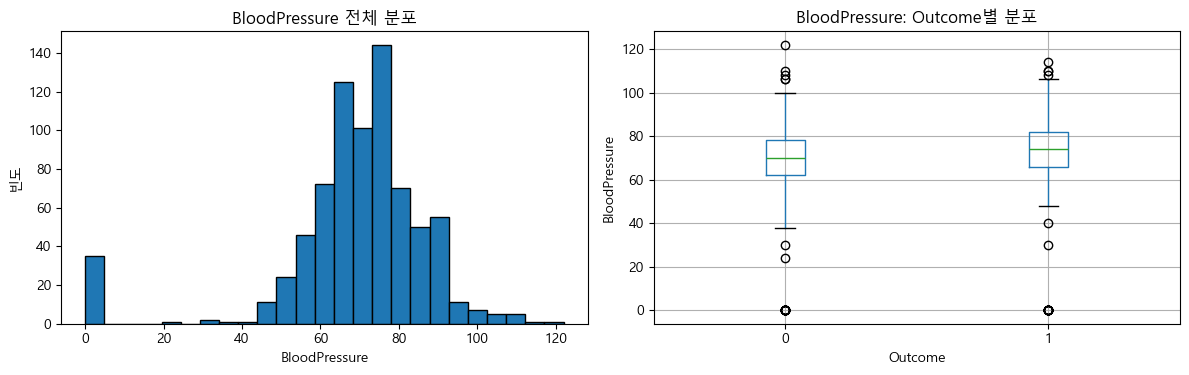

자동 비교
- Outcome=1 집단의 중앙값이 Outcome=0 집단보다 높다.
- 전체 768개 행 중 35개 행에서 0이 확인되었다.


In [76]:
numeric_eda(
    df_raw,
    column="BloodPressure",
    zero_policy="0은 현실적인 혈압 측정값으로 보기 어려우므로 결측값으로 변경"
)

### 4. SkinThickness

삼두근 피부 두께이다. 0은 실제 측정값으로 보기 어려우므로 결측값으로 처리한다.

[SkinThickness]
0의 개수: 227
0의 비율: 29.56%
0 처리 기준: 0은 실제 피부 두께 측정값으로 보기 어려우므로 결측값으로 변경

기술통계


,count,mean,std,min,25%,50%,75%,max
SkinThickness,768.0000,20.5365,15.9522,0.0000,0.0000,23.0000,32.0000,99.0000



Outcome별 통계


,count,mean,median,std,min,max
Outcome,,,,,,
0,500,19.6640,21.0000,14.8899,0,60
1,268,22.1642,27.0000,17.6797,0,99


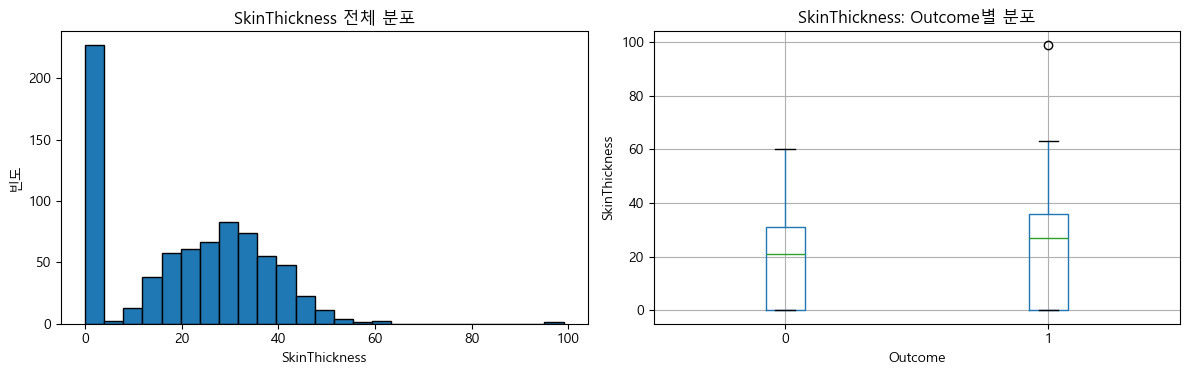

자동 비교
- Outcome=1 집단의 중앙값이 Outcome=0 집단보다 높다.
- 전체 768개 행 중 227개 행에서 0이 확인되었다.


In [77]:
numeric_eda(
    df_raw,
    column="SkinThickness",
    zero_policy="0은 실제 피부 두께 측정값으로 보기 어려우므로 결측값으로 변경"
)

### 5. Insulin

2시간 혈청 인슐린 수치이다. `Outcome`을 이용하지 않고 모든 0을 같은 규칙으로 처리한다.

[Insulin]
0의 개수: 374
0의 비율: 48.70%
0 처리 기준: Outcome과 관계없이 모든 0을 결측값으로 변경

기술통계


,count,mean,std,min,25%,50%,75%,max
Insulin,768.0000,79.7995,115.2440,0.0000,0.0000,30.5000,127.2500,846.0000



Outcome별 통계


,count,mean,median,std,min,max
Outcome,,,,,,
0,500,68.7920,39.0000,98.8653,0,744
1,268,100.3358,0.0000,138.6891,0,846


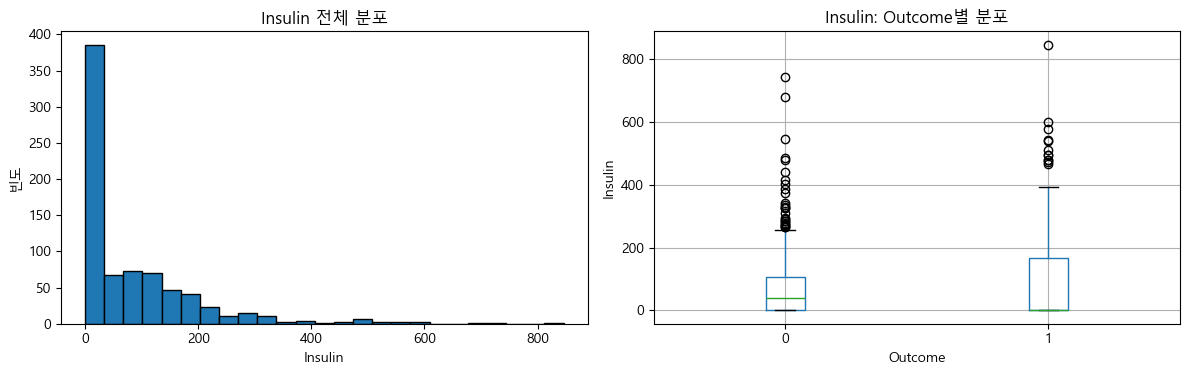

자동 비교
- Outcome=1 집단의 중앙값이 Outcome=0 집단보다 낮다.
- 전체 768개 행 중 374개 행에서 0이 확인되었다.


In [78]:
numeric_eda(
    df_raw,
    column="Insulin",
    zero_policy="Outcome과 관계없이 모든 0을 결측값으로 변경"
)

### 6. BMI

체질량지수이다. BMI 0은 현실적인 값으로 보기 어려우므로 결측값으로 처리한다.

[BMI]
0의 개수: 11
0의 비율: 1.43%
0 처리 기준: 0은 현실적인 BMI로 보기 어려우므로 결측값으로 변경

기술통계


,count,mean,std,min,25%,50%,75%,max
BMI,768.0000,31.9926,7.8842,0.0000,27.3000,32.0000,36.6000,67.1000



Outcome별 통계


,count,mean,median,std,min,max
Outcome,,,,,,
0,500,30.3042,30.0500,7.6899,0.0000,57.3000
1,268,35.1425,34.2500,7.2630,0.0000,67.1000


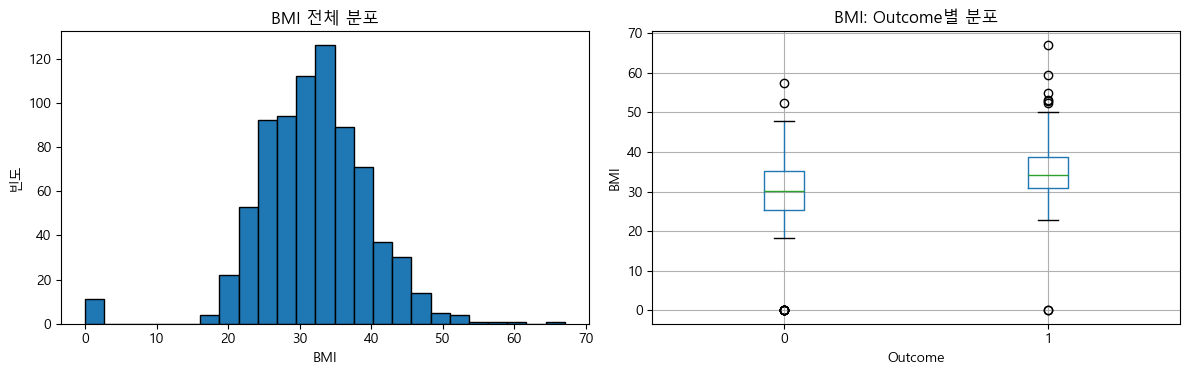

자동 비교
- Outcome=1 집단의 중앙값이 Outcome=0 집단보다 높다.
- 전체 768개 행 중 11개 행에서 0이 확인되었다.


In [79]:
numeric_eda(
    df_raw,
    column="BMI",
    zero_policy="0은 현실적인 BMI로 보기 어려우므로 결측값으로 변경"
)

### 7. DiabetesPedigreeFunction

당뇨병 가족력 정보를 수치화한 변수이다. 0이 나올 수 있으므로 원본값을 유지한다.

[DiabetesPedigreeFunction]
0의 개수: 0
0의 비율: 0.00%
0 처리 기준: 0이 나올 수 있으므로 원본값 유지

기술통계


,count,mean,std,min,25%,50%,75%,max
DiabetesPedigreeFunction,768.0000,0.4719,0.3313,0.0780,0.2437,0.3725,0.6262,2.4200



Outcome별 통계


,count,mean,median,std,min,max
Outcome,,,,,,
0,500,0.4297,0.3360,0.2991,0.0780,2.3290
1,268,0.5505,0.4490,0.3724,0.0880,2.4200


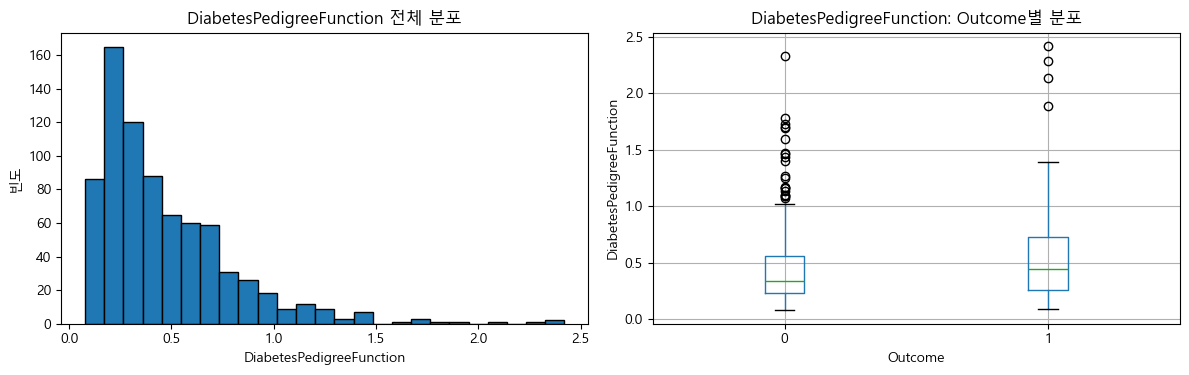

자동 비교
- Outcome=1 집단의 중앙값이 Outcome=0 집단보다 높다.
- 0으로 기록된 값은 확인되지 않았다.


In [80]:
numeric_eda(
    df_raw,
    column="DiabetesPedigreeFunction",
    zero_policy="0이 나올 수 있으므로 원본값 유지"
)

### 8. Age

나이는 실제로 0이 될 수 없다. 데이터에서 0이 발견되면 결측값으로 처리한다.

[Age]
0의 개수: 0
0의 비율: 0.00%
0 처리 기준: 나이 0은 불가능하므로 발견되면 결측값으로 변경

기술통계


,count,mean,std,min,25%,50%,75%,max
Age,768.0000,33.2409,11.7602,21.0000,24.0000,29.0000,41.0000,81.0000



Outcome별 통계


,count,mean,median,std,min,max
Outcome,,,,,,
0,500,31.1900,27.0000,11.6677,21,81
1,268,37.0672,36.0000,10.9683,21,70


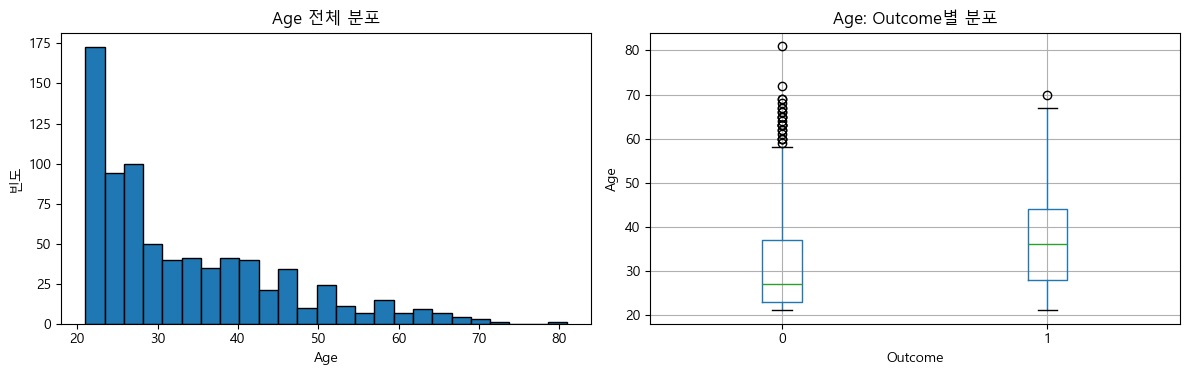

자동 비교
- Outcome=1 집단의 중앙값이 Outcome=0 집단보다 높다.
- 0으로 기록된 값은 확인되지 않았다.


In [81]:
numeric_eda(
    df_raw,
    column="Age",
    zero_policy="나이 0은 불가능하므로 발견되면 결측값으로 변경"
)

# 1-2. 각 데이터 변수 확인 인사이트

1. Pregnancies와 DiabetesPedigreeFunction은 0이 실제로 가능한 값이므로 그대로 사용한다.
2. Glucose, BloodPressure, SkinThickness, Insulin, BMI의 0은 실제 측정값으로 보기 어려워 결측값으로 처리한다.
3. 결측값은 행을 삭제하지 않고 학습 데이터의 중앙값으로 대체하며, 원래 0이었던 값은 missing flag로 따로 표시한다.
4. Outcome별 분포를 비교한 결과 Pregnancies, Glucose는 당뇨병 집단과 비당뇨병 집단 사이에 중앙값 차이가 나타나 예측에 도움이 될 가능성이 있다.
5. 이후 XGBoost 모델을 이용해 각 변수의 실제 예측 기여도와 모델 성능을 확인한다.


# 변수 간 상관관계 확인

상관계수는 두 변수 사이의 선형 관계를 보여 준다.  
상관계수가 낮더라도 XGBoost에서 비선형 관계나 상호작용을 통해 중요한 변수가 될 수 있다.

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.0000,0.1290,0.1410,-0.0820,-0.0740,0.0180,-0.0340,0.5440,0.2220
Glucose,0.1290,1.0000,0.1530,0.0570,0.3310,0.2210,0.1370,0.2640,0.4670
BloodPressure,0.1410,0.1530,1.0000,0.2070,0.0890,0.2820,0.0410,0.2400,0.0650
SkinThickness,-0.0820,0.0570,0.2070,1.0000,0.4370,0.3930,0.1840,-0.1140,0.0750
Insulin,-0.0740,0.3310,0.0890,0.4370,1.0000,0.1980,0.1850,-0.0420,0.1310
BMI,0.0180,0.2210,0.2820,0.3930,0.1980,1.0000,0.1410,0.0360,0.2930
DiabetesPedigreeFunction,-0.0340,0.1370,0.0410,0.1840,0.1850,0.1410,1.0000,0.0340,0.1740
Age,0.5440,0.2640,0.2400,-0.1140,-0.0420,0.0360,0.0340,1.0000,0.2380
Outcome,0.2220,0.4670,0.0650,0.0750,0.1310,0.2930,0.1740,0.2380,1.0000


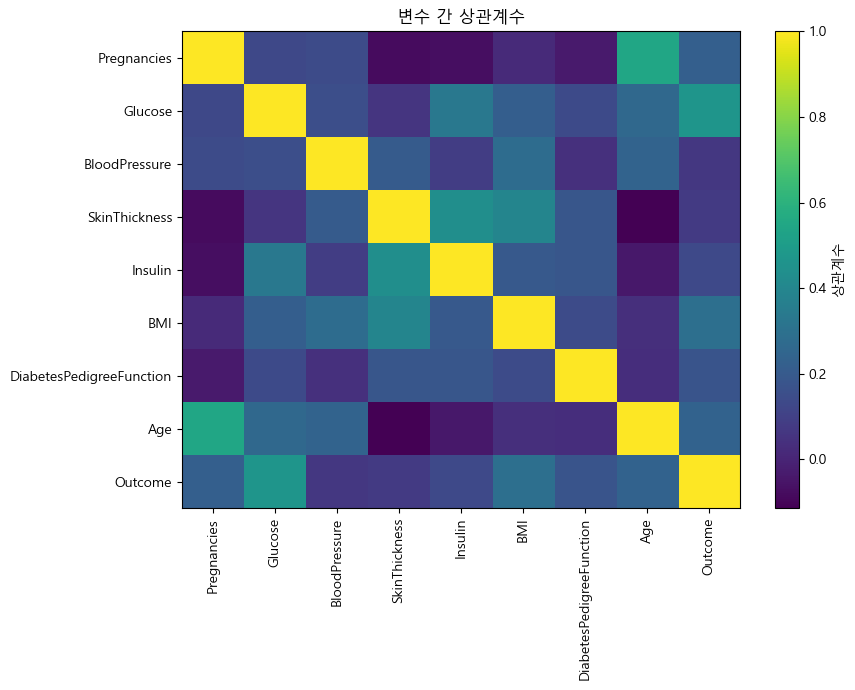

In [82]:
correlation = df_raw.corr(numeric_only=True)

display(correlation.round(3))

plt.figure(figsize=(9, 7))
plt.imshow(correlation, aspect="auto")
plt.colorbar(label="상관계수")
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)
plt.yticks(
    range(len(correlation.index)),
    correlation.index
)
plt.title("변수 간 상관계수")
plt.tight_layout()
plt.show()

# 2. 당뇨병 데이터 전처리

메모) Missing flag

`missing flag`는 원래 값이 비정상적인 0이어서 결측으로 처리되었는지를 나타내는 0/1 파생변수이다.

예를 들어 다음과 같이 처리한다.

- 원래 `Insulin`이 정상값이면 `Insulin_missing = 0`
- 원래 `Insulin`이 0이면 `Insulin_missing = 1`
- 원래 `Insulin=0`은 `NaN`으로 변경
- 이후 학습 데이터의 중앙값으로 `NaN` 대체

이 방식은 모델에 대체된 숫자뿐 아니라 **원래 측정값이 누락되어 있었다는 사실**도 전달한다.

In [83]:
df = df_raw.copy()

# 변수의 의미상 0을 정상 측정값으로 보기 어려운 변수
zero_as_missing_cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "Age"
]

missing_flag_cols = []

for column in zero_as_missing_cols:
    flag_column = f"{column}_missing"

    # 원래 값이 0이었는지 기록
    df[flag_column] = (df[column] == 0).astype(int)

    # 비정상적인 0을 결측값으로 변경
    df[column] = df[column].mask(df[column] == 0, np.nan)

    missing_flag_cols.append(flag_column)

print("0을 결측값으로 처리한 변수:", zero_as_missing_cols)
print("생성한 missing flag:", missing_flag_cols)

display(df.head())

0을 결측값으로 처리한 변수: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']
생성한 missing flag: ['Glucose_missing', 'BloodPressure_missing', 'SkinThickness_missing', 'Insulin_missing', 'BMI_missing', 'Age_missing']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_missing,BloodPressure_missing,SkinThickness_missing,Insulin_missing,BMI_missing,Age_missing
0,6,148.0000,72.0000,35.0000,NaN,33.6000,0.6270,50,1,0,0,0,1,0,0
1,1,85.0000,66.0000,29.0000,NaN,26.6000,0.3510,31,0,0,0,0,1,0,0
2,8,183.0000,64.0000,NaN,NaN,23.3000,0.6720,32,1,0,0,1,1,0,0
3,1,89.0000,66.0000,23.0000,94.0000,28.1000,0.1670,21,0,0,0,0,0,0,0
4,0,137.0000,40.0000,35.0000,168.0000,43.1000,2.2880,33,1,0,0,0,0,0,0


In [84]:
# 결측치 잘 변경되었는지 검토

preprocess_summary = pd.DataFrame({
    "원본 0 개수": [
        (df_raw[column] == 0).sum()
        for column in zero_as_missing_cols
    ],
    "변환 후 결측치 수": [
        df[column].isna().sum()
        for column in zero_as_missing_cols
    ],
    "missing flag 합계": [
        df[f"{column}_missing"].sum()
        for column in zero_as_missing_cols
    ]
}, index=zero_as_missing_cols)

display(preprocess_summary)

,원본 0 개수,변환 후 결측치 수,missing flag 합계
Glucose,5,5,5
BloodPressure,35,35,35
SkinThickness,227,227,227
Insulin,374,374,374
BMI,11,11,11
Age,0,0,0


In [85]:
# 결측치 수 검토

base_feature_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

feature_columns = base_feature_columns + missing_flag_cols

X = df[feature_columns]
y = df["Outcome"]

print("설명변수 개수:", X.shape[1])
print("사용한 설명변수:")
print(feature_columns)

print("\n설명변수별 결측치 수")
display(X.isna().sum().to_frame("결측치 수"))

설명변수 개수: 14
사용한 설명변수:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Glucose_missing', 'BloodPressure_missing', 'SkinThickness_missing', 'Insulin_missing', 'BMI_missing', 'Age_missing']

설명변수별 결측치 수


,결측치 수
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Glucose_missing,0
BloodPressure_missing,0


# 3. 학습 데이터와 검증 데이터 분리

전체 데이터의 75%를 학습 데이터, 25%를 검증 데이터로 사용한다.  
`stratify=y`를 적용하여 두 데이터의 클래스 비율(outcome 비율)이 비슷하게 유지되도록 한다.

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train 크기:", X_train.shape)
print("X_test 크기:", X_test.shape)

split_ratio = pd.DataFrame({
    "전체": y.value_counts(normalize=True).sort_index(),
    "학습": y_train.value_counts(normalize=True).sort_index(),
    "검증": y_test.value_counts(normalize=True).sort_index()
})

display(split_ratio)

X_train 크기: (576, 14)
X_test 크기: (192, 14)


,전체,학습,검증
Outcome,,,
0,0.6510,0.6510,0.6510
1,0.3490,0.3490,0.3490


# 4. 기본 XGBoost 모델 학습

In [87]:
# 모델 평가 함수 생성
# 정확도, 정밀도, 재현율, F1 점수, ROC-AUC를 한 번에 계산하는 함수를 만든다.

def evaluate_model(model, X_data, y_true, dataset_name):
    y_pred = model.predict(X_data)
    y_proba = model.predict_proba(X_data)[:, 1]

    metrics = {
        "데이터": dataset_name,
        "정확도": accuracy_score(y_true, y_pred),
        "정밀도": precision_score(y_true, y_pred, zero_division=0),
        "재현율": recall_score(y_true, y_pred, zero_division=0),
        "F1 점수": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

    return metrics, y_pred, y_proba

In [88]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
class_ratio = negative_count / positive_count

print("학습 데이터 음성 클래스 수:", negative_count)
print("학습 데이터 양성 클래스 수:", positive_count)
print("음성/양성 비율:", round(class_ratio, 4))

학습 데이터 음성 클래스 수: 375
학습 데이터 양성 클래스 수: 201
음성/양성 비율: 1.8657


In [89]:
base_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1
)

base_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", base_xgb)
])

base_model.fit(X_train, y_train)

base_model

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=0, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                    

In [90]:
# 검증 데이터의 실제값과 예측 결과 확인
THRESHOLD = 0.5  # 당뇨병 양성 예측확률이 0.5가 넘으면 1로 예측

prediction_result = pd.DataFrame({
    "실제 Outcome": y_test.to_numpy(),
    "당뇨병 양성 예측확률": base_test_proba
})

prediction_result["예측 Outcome"] = (
    prediction_result["당뇨병 양성 예측확률"] > THRESHOLD
).astype(int)

prediction_result["예측 성공 여부"] = (
    prediction_result["실제 Outcome"]
    == prediction_result["예측 Outcome"]
)

display(prediction_result.head(20))


,실제 Outcome,당뇨병 양성 예측확률,예측 Outcome,예측 성공 여부
0,0,0.0586,0,True
1,0,0.1338,0,True
2,0,0.0367,0,True
3,0,0.3856,0,True
4,0,0.1507,0,True
5,1,0.7381,1,True
6,0,0.2450,0,True
7,0,0.5678,1,False
8,0,0.1093,0,True
9,1,0.1791,0,False


In [91]:
# 기본 모델 평가 (evaluate_model 사용)

base_train_metrics, base_train_pred, base_train_proba = evaluate_model(
    base_model,
    X_train,
    y_train,
    "학습 데이터"
)

base_test_metrics, base_test_pred, base_test_proba = evaluate_model(
    base_model,
    X_test,
    y_test,
    "검증 데이터"
)

base_result = pd.DataFrame([
    base_train_metrics,
    base_test_metrics
]).set_index("데이터")

display(base_result.round(4))

,정확도,정밀도,재현율,F1 점수,ROC-AUC
데이터,,,,,
학습 데이터,0.9010,0.8750,0.8358,0.8550,0.9682
검증 데이터,0.7292,0.6271,0.5522,0.5873,0.8142


## XGboost 모델 평가

기본 모델 평가 (evaluate_model 사용) 를 통하여 
예측 확률이 0.5 이상이면 1, 0.5 미만이면 0으로 예측을 하는 XGboost 모델을 만들었다.
검증 데이터(test data)에서는 정확도가 0.7292로서 
모델이 약 72.92%의 정확도를 가진다고 볼 수 있다.

또한, 의료 데이터에서는 실제로 병이 있는데 병이 없다고 예측하는 것이 가장 큰 오류이기 때문에
재현율값 또한 중요하다.
검증 데이터(test data)에서 재현율이 0.5522으로 나왔다.
이는 실제 당뇨병 환자 중 약 55.22%는 당뇨병으로 찾아냈지만, 약 44.78%는 실제로 당뇨병 환자인데도 정상으로 잘못 판단했다고 볼 수 있다.

결론 : 
정확도는 약 72.92%로 괜찮은 수치를 보이나, 재현율이 약 55.22%로서 낮은 수치를 보이는 것에 주의해야한다.